In [87]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Standard constants
R_SUN_IN_KM = 696340.0
R_EARTH_IN_KM = 6371.0
AU_IN_KM = 149597870.7
G = 6.67430e-11
M_SUN_KG = 1.98847e30

# Kepler-10 stellar properties
R_star_solar = 1.065
M_star_solar = 0.910

# Download and normalise light curve
search_result = lk.search_lightcurve("Kepler-10", mission="Kepler", quarter=2)
lc_raw = search_result.download()
lc_norm = lc_raw.remove_nans().normalize()

/Users/soSophiephiemainprize/miniforge3/lib/python3.12/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 3 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [ ]:
# Run BLS search to find exact period, T0, and duration automatically
periodogram = lc_norm.to_periodogram(
    method="bls", period=np.linspace(0.8, 0.9, 10000)
)
best_period = float(periodogram.period_at_max_power.value)
best_t0 = float(periodogram.transit_time_at_max_power.value)
best_duration = float(periodogram.duration_at_max_power.value)

# Create transit mask manually using numpy to avoid Astropy/Lightkurve unmasked output error
time_vals = np.array(lc_norm.time.value, dtype=float)
phase_calc = (
    time_vals - best_t0 + 0.5 * best_period
) % best_period - 0.5 * best_period
transit_mask = np.abs(phase_calc) < (0.5 * best_duration)

# Flatten with the boolean mask applied
lc_flat = lc_norm.flatten(window_length=101, mask=transit_mask)
lc_cleaned = lc_flat.remove_outliers(sigma=5)

# Phase-fold and bin
folded_lc = lc_cleaned.fold(period=best_period, epoch_time=best_t0)
binned_lc = folded_lc.bin(time_bin_size=0.002)

phase_binned = binned_lc.time.value
flux_binned = binned_lc.flux.value



In [89]:
# Trapezoidal transit model definition
def transit_model(t, depth, duration, t0=0.0, baseline=1.0):
    model_flux = np.full_like(t, baseline)
    half_dur = duration / 2.0
    ingress = 0.15 * half_dur

    in_idx = (t >= (t0 - half_dur)) & (t < (t0 - half_dur + ingress))
    model_flux[in_idx] = baseline - depth * (
        (t[in_idx] - (t0 - half_dur)) / ingress
    )

    flat_idx = (t >= (t0 - half_dur + ingress)) & (
        t <= (t0 + half_dur - ingress)
    )
    model_flux[flat_idx] = baseline - depth

    eg_idx = (t > (t0 + half_dur - ingress)) & (t <= (t0 + half_dur))
    model_flux[eg_idx] = baseline - depth * (
        1.0 - (t[eg_idx] - (t0 + half_dur - ingress)) / ingress
    )

    return model_flux

In [90]:
# Fit transit model
p0 = [0.00015, best_duration, 0.0, 1.0]
bounds = ([1e-5, 0.01, -0.02, 0.999], [0.0005, 0.2, 0.02, 1.001])

popt, pcov = curve_fit(
    transit_model, phase_binned, flux_binned, p0=p0, bounds=bounds
)
fit_depth, fit_duration, fit_t0, fit_baseline = popt

# Calculate physical properties
rp_over_rs = np.sqrt(fit_depth)
rp_earth = (rp_over_rs * R_star_solar * R_SUN_IN_KM) / R_EARTH_IN_KM

p_seconds = best_period * 86400.0
m_star_kg = M_star_solar * M_SUN_KG
a_meters = (G * m_star_kg * (p_seconds**2) / (4 * np.pi**2)) ** (1 / 3)
a_au = (a_meters / 1000.0) / AU_IN_KM

In [91]:
# Output final results
print("Step 4 parameter estimates")
print(f"Transit Depth (ΔF/F) : {fit_depth*1e6:.1f} ppm")
print(f"Transit Duration     : {fit_duration*24:.2f} hours")
print(f"Orbital Period       : {best_period:.5f} days")
print(f"Stellar Radius (R*)  : {R_star_solar:.3f} R_Sun")
print(f"Planet Radius (Rp)   : {rp_earth:.2f} Earth Radii")
print(f"Semi-Major Axis (a)  : {a_au:.4f} AU")

Step 4 parameter estimates
Transit Depth (ΔF/F) : 178.1 ppm
Transit Duration     : 1.90 hours
Orbital Period       : 0.83748 days
Stellar Radius (R*)  : 1.065 R_Sun
Planet Radius (Rp)   : 1.55 Earth Radii
Semi-Major Axis (a)  : 0.0169 AU


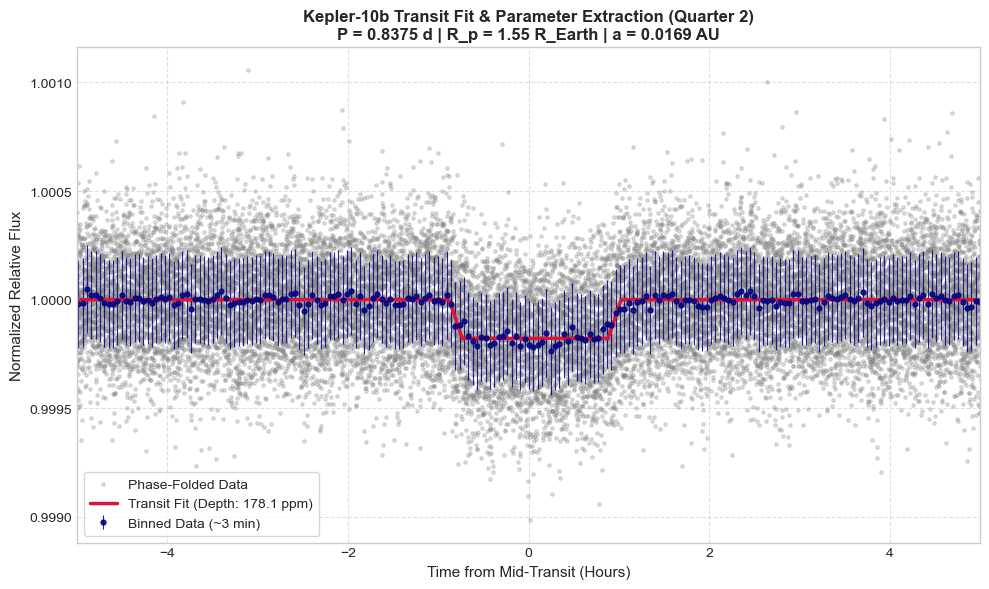

In [95]:
# Generate Plot
# Generate high-resolution model timeline (converted to hours for plotting)
time_model_days = np.linspace(phase_binned.min(), phase_binned.max(), 1000)
flux_model = transit_model(time_model_days, *popt)

time_unbinned_hours = folded_lc.time.value * 24.0
time_binned_hours = phase_binned * 24.0
time_model_hours = time_model_days * 24.0

fig, ax = plt.subplots(figsize=(10, 6))

# Unbinned scatter
ax.scatter(
    time_unbinned_hours,
    folded_lc.flux.value,
    color="gray",
    alpha=0.25,
    s=6,
    label="Phase-Folded Data",
)

# Binned data points with error bars
yerr_bin = binned_lc.flux_err.value if binned_lc.flux_err is not None else None

# If flux_err is pulling uncalibrated noise, scale it by sqrt(N) or cap visually:
ax.errorbar(
    time_binned_hours,
    flux_binned,
    yerr=yerr_bin,
    fmt="o",
    color="navy",
    ecolor="navy",
    elinewidth=0.8,
    capsize=0,
    markersize=3.5,
    alpha=0.85,
    label="Binned Data (~3 min)",
)

# Best-fit model line
ax.plot(
    time_model_hours,
    flux_model,
    color="crimson",
    linewidth=2.5,
    label=f"Transit Fit (Depth: {fit_depth*1e6:.1f} ppm)",
)

# Formatting
ax.set_xlim(-5.0, 5.0)  # Focus on ±5 hours around mid-transit
ax.set_xlabel("Time from Mid-Transit (Hours)", fontsize=11)
ax.set_ylabel("Normalized Relative Flux", fontsize=11)
ax.set_title(
    f"Kepler-10b Transit Fit & Parameter Extraction (Quarter 2)\n"
    f"P = {best_period:.4f} d | R_p = {rp_earth:.2f} R_Earth | a = {a_au:.4f} AU",
    fontsize=12,
    fontweight="bold",
)
ax.legend(loc="lower left", frameon=True)
ax.grid(True, linestyle="--", alpha=0.6)

# Save plot
output_path_bls = "../figures/04_transit_model_fit.png"
plt.tight_layout()
plt.savefig(output_path_bls, dpi=300, bbox_inches="tight")
plt.show()